<a href="https://colab.research.google.com/github/lenmecc/miniature-enigma/blob/main/Proyecto_NLP_Tweeter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



## **PROYECTO INTEGRADOR 2: Análisis de textos de Tweets de aerolíneas.**

**Declaración del problema :** Una nueva aerolínea contrató a nuestra agencia de Data Analytics para realizar una investigación sobre la percepción del público en Twitter hacia las compañías ya posicionadas en el mercado estadounidense. Este estudio clasificará los tweets en positivos, negativos y neutrales, seguido de una categorización de las quejas (como 'vuelo retrasado' o 'servicio grosero'). El análisis se abordará aplicando técnicas de NLP para construir un modelo de clasificación de textos y su interpretación.


**Dataset**: "tweeter"

### **Importando las librerías necesarias**



In [77]:
# Para leer y manipular los datos
import pandas as pd
pd.set_option('max_colwidth', None)

# para los gráficos
import matplotlib.pyplot as plt
from matplotlib import cycler
colors = cycler('color',
                ['#EE6666', '#3388BB', '#9988DD',
                 '#EECC55', '#88BB44', '#FFBBBB'])
plt.rc('axes', facecolor='#E6E6E6', edgecolor='none',
       axisbelow=True, grid=True, prop_cycle=colors)
plt.rc('grid', color='w', linestyle='solid')
plt.rc('xtick', direction='out', color='black')
plt.rc('ytick', direction='out', color='black')
plt.rc('patch', edgecolor='#E6E6E6')
plt.rc('lines', linewidth=2)
import seaborn as sns

# Apoya a mostrar las imágenes
from PIL import Image

# Apoya en la remoción de puntuación
import string

# Apoya en la creación del counter
from collections import Counter

# Apoya en la creación de train y test
from sklearn.model_selection import train_test_split

#Importa las clases de la vectorización
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

# Apoya en el modelo Random Forest
from sklearn.ensemble import RandomForestClassifier

# Métricas de ajuste del modelo
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

In [78]:
#from google.colab import drive
#drive.mount('/content/drive')

### **Carga de los datos**


In [79]:
from google.colab import files
uploaded = files.upload()

Saving Tweets.csv to Tweets (2).csv


In [80]:
messages = pd.read_csv("Tweets.csv", index_col = [0])

In [81]:
# Creando una copia del dataframe
data = messages.copy()

### **Explorando los datos**

In [82]:

data.head(5)

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
5.703060e+17,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,24/02/2015 11:35,NaN,Eastern Time (US & Canada)
5.703010e+17,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,24/02/2015 11:15,NaN,Pacific Time (US & Canada)
5.703010e+17,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,24/02/2015 11:15,Lets Play,Central Time (US & Canada)
5.703010e+17,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",NaN,24/02/2015 11:15,NaN,Pacific Time (US & Canada)
5.703010e+17,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,24/02/2015 11:14,NaN,Pacific Time (US & Canada)


In [83]:

data.tail(5)

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
5.695880e+17,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different flight to Chicago.,NaN,22/02/2015 12:01,NaN,NaN
5.695870e+17,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flight. No warnings or communication until we were 15 minutes Late Flight. That's called shitty customer svc,NaN,22/02/2015 11:59,Texas,NaN
5.695870e+17,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to #BlackBerry10,NaN,22/02/2015 11:59,"Nigeria,lagos",NaN
5.695870e+17,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my flight, and don't answer your phones! Any other suggestions so I can make my commitment??",NaN,22/02/2015 11:59,New Jersey,Eastern Time (US & Canada)
5.695870e+17,neutral,0.6771,NaN,0.0000,American,NaN,daviddtwu,NaN,0,@AmericanAir we have 8 ppl so we need 2 know how many seats are on the next flight. Plz put us on standby for 4 people on the next flight?,NaN,22/02/2015 11:58,"dallas, TX",NaN


In [84]:
# Revisando las dimensiones de la base
data.shape

(14640, 14)

In [85]:

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14640 entries, 5.70306e+17 to 5.69587e+17
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   airline_sentiment             14640 non-null  object 
 1   airline_sentiment_confidence  14640 non-null  float64
 2   negativereason                9178 non-null   object 
 3   negativereason_confidence     10522 non-null  float64
 4   airline                       14640 non-null  object 
 5   airline_sentiment_gold        40 non-null     object 
 6   name                          14640 non-null  object 
 7   negativereason_gold           32 non-null     object 
 8   retweet_count                 14640 non-null  int64  
 9   text                          14640 non-null  object 
 10  tweet_coord                   1019 non-null   object 
 11  tweet_created                 14640 non-null  object 
 12  tweet_location                9907 non-null   obj

In [86]:
# Revisando los registros duplicados
data.duplicated().sum()

np.int64(36)

In [87]:
data.drop_duplicates(inplace = True)

In [88]:
data.duplicated().sum()

np.int64(0)

In [89]:
# Revisando los missing values
data.isna().sum()

,0
airline_sentiment,0
airline_sentiment_confidence,0
negativereason,5445
negativereason_confidence,4101
airline,0
airline_sentiment_gold,14564
name,0
negativereason_gold,14572
retweet_count,0
text,0


Eliminamos columnas que no aportan al objetivo del modelo, en este caso la columna "negativereason" contiene 5445 datos faltantes, sin embargo seria interesante aplicar una nube de palabras para las respuestas de esta columna.

In [90]:
data.drop(columns = ["negativereason_confidence","airline_sentiment_gold","name","negativereason_gold","retweet_count","tweet_coord","tweet_created","tweet_location","user_timezone","airline_sentiment_confidence"], inplace = True)

In [91]:
data.columns

Index(['airline_sentiment', 'negativereason', 'airline', 'text'], dtype='object')

In [92]:
df_airline = data["airline"].value_counts(normalize=True)*100

In [93]:
df_airline.head()

,proportion
airline,
United,26.170912
US Airways,19.946590
American,18.645577
Southwest,16.570803
Delta,15.215010


In [94]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14604 entries, 5.70306e+17 to 5.69587e+17
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   airline_sentiment  14604 non-null  object
 1   negativereason     9159 non-null   object
 2   airline            14604 non-null  object
 3   text               14604 non-null  object
dtypes: object(4)
memory usage: 570.5+ KB


In [95]:
sentiment = data['airline_sentiment'].value_counts(True)


# **Observaciones:**

* Hay un total  máximo de 14,604 filas y 14 columnas en el conjunto de datos.
* Tenemos variables numericas y string.
+ Hay valores 36 duplicados en los datos.
* Hay valores nulos en el conjunto de datos.
* Hay columnas que no aportan a nuestro objetivo de analisis, las cuales fueron eliminadas.
* El data set contiene 62% de datos negativos,
  21 % datos neutrales y 16% datos positivos.

In [96]:
# Esta librería expande las contracciones de palabras usadas
!pip install contractions

In [97]:
# Ayuda a extraer los datos utilizando expresiones regulares.
import re                                   # Importa el módulo de expresiones regulares (regex) en Python, que se utiliza para buscar y manipular cadenas de texto basadas en patrones.
import nltk                                 # Importa la biblioteca Natural Language Toolkit (nltk), que es una biblioteca completa para trabajar con texto en lenguaje natural.
import contractions                         # mporta el módulo de contractions, que se utiliza para expandir las contracciones en inglés (por ejemplo, convertir "don't" en "do not").
nltk.download('punkt')                      # punkt es un tokenizador
nltk.download('all')                        # Descarga todos los paquetes disponibles en NLTK.

from nltk.corpus import stopwords           # Importa la colección de stop words en inglés de NLTK.
from nltk import word_tokenize              # Importa la función word_tokenize de NLTK para tokenizar los datos.
# Utilizado en la lematización.
from nltk.stem import WordNetLemmatizer     # Importa la clase WordNetLemmatizer de NLTK, que se utiliza para la lematización.
                                            # La lematización es el proceso de reducir las palabras a su forma base o raíz (por ejemplo, convertir "corriendo" en "correr").

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru 

**Pre-procesamiento de datos (texto)**

In [98]:
# Función para el preprocesamiento de texto.
# El pre-procesamientio ayuda a eliminar y sumarizar los datos, con la finalidad
# de que el modelo y los esfuerzos de vectorización se concentren en palabras
# relevantes
def clean_text(df, punctuations=r'''!()-[]{};:'"\,<>./?@#$%^&*_~'''):
    """
    Es un método para "limpiar" el texto
    """
    # Eliminar URL's
    string = re.sub(r'https?://\S+|www\.\S+', '', df)

    # Eliminar elementos de HTML
    string = re.sub(r'<.*?>', '', df)

    # Eliminar la puntuación utilizando una expresión regular, es decir,
    # eliminar cualquier cosa que no sea un carácter de palabra o espacio en blanco.

    string = re.sub(r'[^\w\s]', '', df)

    # Convertir el texto a minúsculas.
    string = string.lower()

    # Eliminar las stop words
    string = ' '.join([word for word in string.split() if word not in stopwords.words('english')])

    # Eliminanlos espacios en blanco
    string = re.sub(r'\s+', ' ', string).strip()

    # Tokeniza los datos
    string = word_tokenize(string)

    # Elimina los números
    string=[s for s in string if s.isalpha()]

    #Lematiza los datos
    string= [WordNetLemmatizer().lemmatize(i) for i in string]

    #Corregir las contracciones (por ejemplo: "'cause" por "because", "could've" por "could have", etc.).
    string = ' '.join([contractions.fix(word) for word in string])


    return string
    #return " ".join(string)


In [99]:
data["text"] = data["text"].astype(str)
data['clean_text'] = data['text'].apply(clean_text)

#**Análisis exploratorio**

**Graficamos la distribución de todos los tweets entre cada aerolínea**

In [100]:
import plotly.express as px
fig = px.bar(df_airline,
             x=df_airline.index,
             y=df_airline.values,
             title='Distribución de Aerolineas Mencionadas',
             text=df_airline.values)

fig.update_traces(texttemplate='%{text:.2f}%', textposition='inside')
fig.show()

**Graficamos la distribución del sentimiento en todos los tweets**

In [101]:
import plotly.express as px

fig = px.pie(sentiment,
             values=sentiment.values,
             names=sentiment.index,
             title='Distribución de Sentimiento',
             hole=0.3)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [102]:
data.columns

Index(['airline_sentiment', 'negativereason', 'airline', 'text', 'clean_text'], dtype='object')

**Ahora graficamos la distribución del sentimiento de los tweets para cada aerolínea**

In [103]:
df_aerolinea = data.groupby('airline')['airline_sentiment'].value_counts(normalize=True).unstack(fill_value=0) * 100


In [104]:
import plotly.express as px

fig = px.bar(df_aerolinea,
             x=df_aerolinea.index,
             y=['negative', 'neutral', 'positive'],
             title='Distribución de Sentimiento por Aerolínea',
             labels={'x': 'Aerolínea', 'value': 'Porcentaje'})

fig.update_layout(barmode='stack')
fig.show()

Se observa claramente que la aerolínea con la mayor proporción de comentarios positivos fue Virgin America, alcanzando un 30%; además, posee el menor índice de comentarios negativos, con un 35%. En contraparte, la compañía con el desempeño más bajo en redes sociales fue US Airways, registrando un 77% de menciones negativas.

La recomendación estratégica para el cliente será realizar un benchmark con Virgin America para identificar las mejores prácticas que las distinguen y generan tan alta aceptación entre los viajeros..

**Ahora graficamos la distribución de todas las razones negativas**

In [105]:
negativereason = data['negativereason'].value_counts(normalize=True) * 100

<Axes: xlabel='negativereason'>

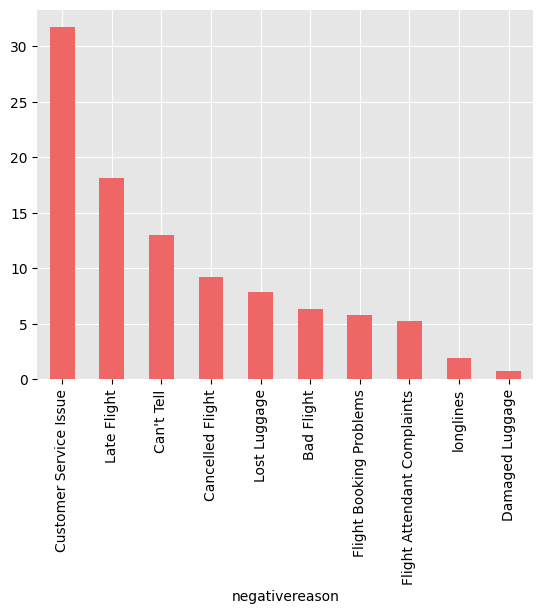

In [106]:
negativereason.plot(kind="bar")

Echemos un vistazo a los datos de texto para comprender las palabras más frecuentes.

In [107]:
# mensajes spam
data_negative = data[data['airline_sentiment'] == 'negative']

# mensajes ham
data_neutral = data[data['airline_sentiment'] == 'neutral']

data_positive = data[data['airline_sentiment'] == 'positive']

Graficar la distribución de todos los tweets entre cada aerolínea y graficar la distribución del sentimiento en todos los tweets.

In [108]:
data_negative.head(5)

,airline_sentiment,negativereason,airline,text,clean_text
tweet_id,,,,,
5.703010e+17,negative,Bad Flight,Virgin America,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",virginamerica really aggressive blast obnoxious entertainment guest face amp little recourse
5.703010e+17,negative,Can't Tell,Virgin America,@VirginAmerica and it's a really big bad thing about it,virginamerica really big bad thing
5.703010e+17,negative,Can't Tell,Virgin America,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's really the only bad thing about flying VA,virginamerica seriously would pay flight seat did not playing really bad thing flying va
5.702820e+17,negative,Late Flight,Virgin America,@VirginAmerica SFO-PDX schedule is still MIA.,virginamerica sfopdx schedule still mia
5.702770e+17,negative,Bad Flight,Virgin America,@VirginAmerica I flew from NYC to SFO last week and couldn't fully sit in my seat due to two large gentleman on either side of me. HELP!,virginamerica flew nyc sfo last week could not fully sit seat due two large gentleman either side help


In [109]:
# Esta función apoya en la creación de n-gramas
def top_n_ngram(corpus, n = None, ngram = 1):
    vec = CountVectorizer(stop_words = 'english',ngram_range=(ngram,ngram)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis =0)
    words_freq = [(word,sum_words[0,idx]) for word,idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq,key = lambda x:x[1],reverse = True)
    return words_freq[:n]

**UNIGRAMAS Y BIGRAMAS**


<Axes: xlabel='Frequent Words in positive comments'>

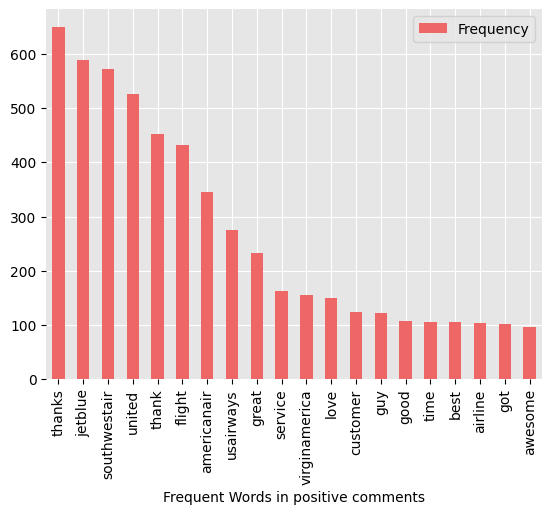

In [110]:
words1 = top_n_ngram(data_positive['clean_text'], 20, 1)
df_s = pd.DataFrame(words1, columns=['Frequent Words in positive comments', 'Frequency'])
df_s.plot(kind='bar', x='Frequent Words in positive comments')

<Axes: xlabel='Frequent Words in positive comments'>

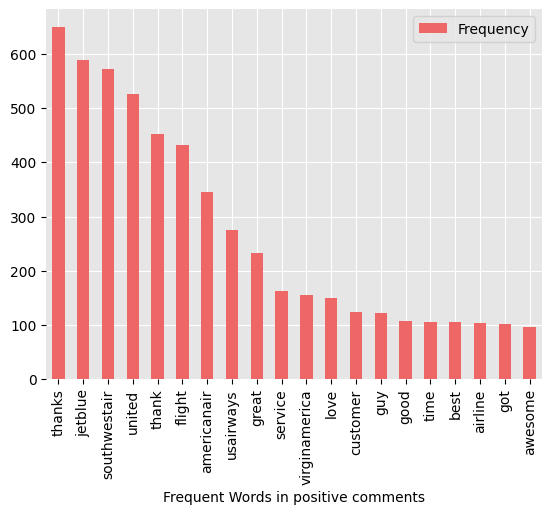

In [111]:
#Aplicaremos un bigrama
words1_2 = top_n_ngram(data_positive['clean_text'], 20, 2)
df_s = pd.DataFrame(words1, columns=['Frequent Words in positive comments', 'Frequency'])
df_s.plot(kind='bar', x='Frequent Words in positive comments')

Es interesante notar que las aerolíneas con comentarios positivos en Twitter mantienen un servicio al cliente sólido, factor que se menciona de forma consistente en los textos analizados. Incluso se han identificado compañías específicas que destacan en este rubro. La recomendación para el cliente será prestar especial atención al servicio al cliente que ofrecen estas compañías, dado que es un atributo altamente valorado por el viajero.

<Axes: xlabel='Frequent Words in negative Texts'>

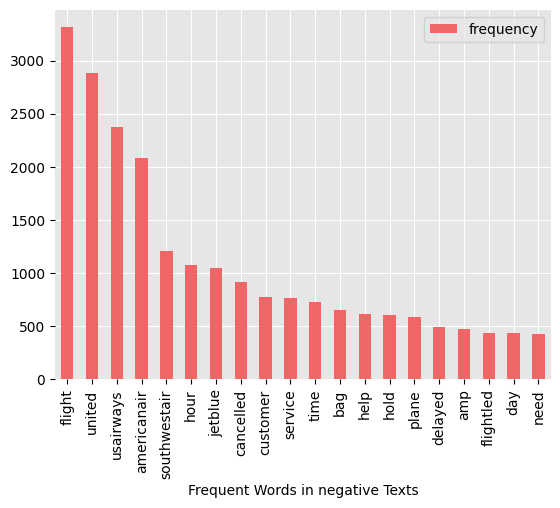

In [112]:
#Generemos el uni grama para los comentarios negativos
words2 = top_n_ngram(data_negative['clean_text'], 20, 1)
df_h = pd.DataFrame(words2, columns=['Frequent Words in negative Texts', 'frequency'])
df_h.plot(kind='bar', x='Frequent Words in negative Texts')

<Axes: xlabel='Frequent Words in negative Texts'>

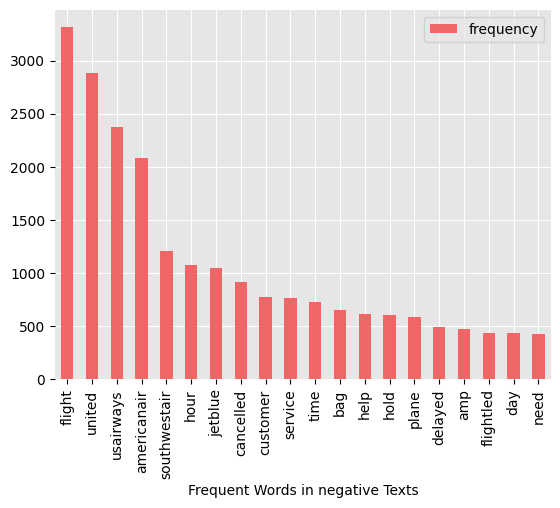

In [113]:
#Generemos el uni grama para los comentarios negativos
words2_1 = top_n_ngram(data_negative['clean_text'], 20, 2)
df_h = pd.DataFrame(words2, columns=['Frequent Words in negative Texts', 'frequency'])
df_h.plot(kind='bar', x='Frequent Words in negative Texts')

Otro hallazgo relevante es que la mayoría de los comentarios negativos mencionan el servicio al cliente. Asimismo, gran parte de las inconformidades del viajero se relacionan con la cancelación de vuelos, el cumplimiento de horarios, los retrasos y problemas al momento de realizar la reserva

<Axes: xlabel='Frequent Words in all comments'>

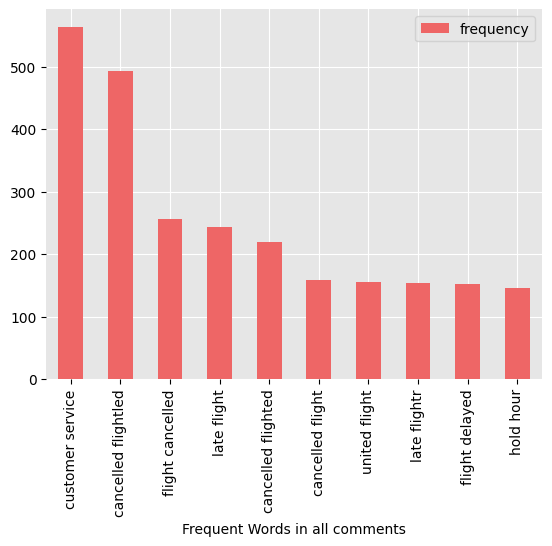

In [114]:
#Generemos un uni grama para todos los comentarios
words3 = top_n_ngram(data['clean_text'], 10, 2)
df_w = pd.DataFrame(words3, columns=['Frequent Words in all comments', 'frequency'])
df_w.plot(kind='bar', x='Frequent Words in all comments')

**Ahora creamos una nube de palabras para lo sentimientos positivos y negativos por separado.**

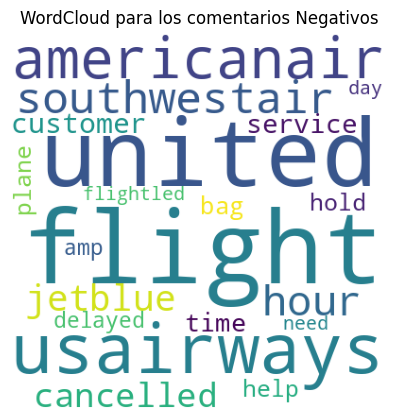

In [115]:
from wordcloud import WordCloud

# Asegurémonos de que words1 es un diccionario para WordCloud
word_freq_dict = dict(words2)

# Crear el objeto WordCloud
wordcloud = WordCloud(width = 400, height = 400,
                background_color ='white',
                min_font_size = 5).generate_from_frequencies(word_freq_dict)

# Mostrar la nube de palabras
plt.figure(figsize = (4, 4), facecolor = None)
plt.title("WordCloud para los comentarios Negativos")
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

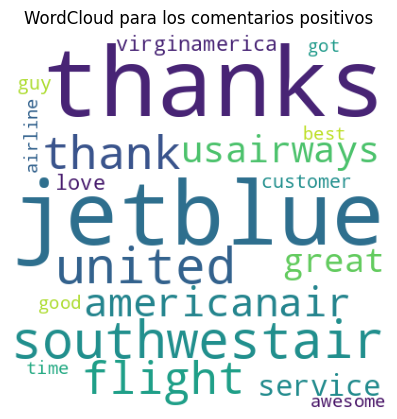

In [116]:
from wordcloud import WordCloud

# Asegurémonos de que words1 es un diccionario para WordCloud
word_freq_dict = dict(words1)

# Crear el objeto WordCloud
wordcloud = WordCloud(width = 400, height = 400,
                background_color ='white',
                min_font_size = 5).generate_from_frequencies(word_freq_dict)

# Mostrar la nube de palabras
plt.figure(figsize = (4, 4), facecolor = None)
plt.title("WordCloud para los comentarios positivos")
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

Ahora creemos los vectores para los datos de texto utilizando las técnicas de Bag-of-Words y TF-IDF.

### **Bag-of-Words**



In [117]:
cv = CountVectorizer()

# Ajustar y transformar los datos de texto
vectors = cv.fit_transform(data['clean_text']).toarray()

# Obtener el tamaño del vocabulario
vocab_size = len(cv.vocabulary_)

print("Tamaño del vocabulario: ", vocab_size)
print("Vocabulario: ", cv.vocabulary_)

Tamaño del vocabulario:  12026
Vocabulario:  {'virginamerica': 11391, 'dhepburn': 2812, 'said': 9146, 'plus': 8059, 'you': 11966, 'have': 4666, 'added': 131, 'commercial': 2030, 'experience': 3580, 'tacky': 10332, 'did': 2826, 'not': 7281, 'today': 10705, 'must': 6973, 'mean': 6588, 'need': 7061, 'take': 10344, 'another': 497, 'trip': 10877, 'really': 8549, 'aggressive': 219, 'blast': 1134, 'obnoxious': 7383, 'entertainment': 3378, 'guest': 4552, 'face': 3636, 'amp': 426, 'little': 6206, 'recourse': 8611, 'big': 1082, 'bad': 849, 'thing': 10560, 'seriously': 9397, 'would': 11855, 'pay': 7806, 'flight': 3877, 'seat': 9306, 'playing': 8021, 'flying': 3990, 'va': 11292, 'yes': 11949, 'nearly': 7058, 'every': 3482, 'time': 10650, 'fly': 3978, 'vx': 11440, 'ear': 3177, 'worm': 11826, 'will': 11720, 'go': 4383, 'away': 802, 'missed': 6801, 'prime': 8260, 'opportunity': 7526, 'men': 6648, 'without': 11763, 'hat': 4657, 'parody': 7738, 'well': 11602, 'didntbut': 2829, 'amazing': 387, 'arrived'

In [118]:
# Creando la vetorización bajo Bag of Words
# Estableciendo un máximo de 200 features
cv = CountVectorizer(max_features = 200)

In [119]:
# Ajustar y transformar en vectores a partir de los datos de texto.
vectors = cv.fit_transform(data['clean_text']).toarray()

In [120]:
# Mostrando las palabras únicas identificadas junto con sus índices.
print("Vocabulario: ", cv.vocabulary_)
# Resumiendo los textos codificados.
print(vectors)

Vocabulario:  {'virginamerica': np.int64(181), 'said': np.int64(144), 'you': np.int64(199), 'have': np.int64(78), 'experience': np.int64(53), 'did': np.int64(44), 'not': np.int64(120), 'today': np.int64(168), 'need': np.int64(114), 'take': np.int64(159), 'another': np.int64(11), 'trip': np.int64(174), 'really': np.int64(135), 'amp': np.int64(10), 'bad': np.int64(17), 'thing': np.int64(164), 'would': np.int64(195), 'pay': np.int64(126), 'flight': np.int64(59), 'seat': np.int64(146), 'flying': np.int64(65), 'yes': np.int64(197), 'time': np.int64(167), 'fly': np.int64(64), 'will': np.int64(192), 'go': np.int64(72), 'missed': np.int64(111), 'well': np.int64(190), 'hour': np.int64(84), 'are': np.int64(14), 'good': np.int64(74), 'know': np.int64(93), 'because': np.int64(20), 'much': np.int64(113), 'better': np.int64(22), 'great': np.int64(76), 'already': np.int64(6), 'even': np.int64(51), 'yet': np.int64(198), 'am': np.int64(8), 'travel': np.int64(172), 'thanks': np.int64(162), 'still': np.i

In [121]:
print(vectors.shape)

(14604, 200)


In [122]:
vectors[0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [123]:
data.tail(5)

,airline_sentiment,negativereason,airline,text,clean_text
tweet_id,,,,,
5.695880e+17,positive,NaN,American,@AmericanAir thank you we got on a different flight to Chicago.,americanair thank got different flight chicago
5.695870e+17,negative,Customer Service Issue,American,@AmericanAir leaving over 20 minutes Late Flight. No warnings or communication until we were 15 minutes Late Flight. That's called shitty customer svc,americanair leaving minute late flight warning communication minute late flight that is called shitty customer svc
5.695870e+17,neutral,NaN,American,@AmericanAir Please bring American Airlines to #BlackBerry10,americanair please bring american airline
5.695870e+17,negative,Customer Service Issue,American,"@AmericanAir you have my money, you change my flight, and don't answer your phones! Any other suggestions so I can make my commitment??",americanair money change flight do not answer phone suggestion make commitment
5.695870e+17,neutral,NaN,American,@AmericanAir we have 8 ppl so we need 2 know how many seats are on the next flight. Plz put us on standby for 4 people on the next flight?,americanair people need know many seat next flight plz put you standby people next flight


In [124]:
# Función para imprimir el informe de clasificación y obtener una matriz de confusión en un formato adecuado.
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize = (8, 5))

    sns.heatmap(cm, annot = True,  fmt = '.2f', xticklabels = ['Positive', 'Negative'], yticklabels = ['Positive', 'Negative'])

    plt.ylabel('Actual')

    plt.xlabel('Predicted')

    plt.show()

# **Construcción del modelo: Random Forest**

In [125]:
data.head(10)

,airline_sentiment,negativereason,airline,text,clean_text
tweet_id,,,,,
5.703060e+17,neutral,NaN,Virgin America,@VirginAmerica What @dhepburn said.,virginamerica dhepburn said
5.703010e+17,positive,NaN,Virgin America,@VirginAmerica plus you've added commercials to the experience... tacky.,virginamerica plus you have added commercial experience tacky
5.703010e+17,neutral,NaN,Virgin America,@VirginAmerica I didn't today... Must mean I need to take another trip!,virginamerica did not today must mean need take another trip
5.703010e+17,negative,Bad Flight,Virgin America,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",virginamerica really aggressive blast obnoxious entertainment guest face amp little recourse
5.703010e+17,negative,Can't Tell,Virgin America,@VirginAmerica and it's a really big bad thing about it,virginamerica really big bad thing
5.703010e+17,negative,Can't Tell,Virgin America,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's really the only bad thing about flying VA,virginamerica seriously would pay flight seat did not playing really bad thing flying va
5.703010e+17,positive,NaN,Virgin America,"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)",virginamerica yes nearly every time fly vx ear worm will not go away
5.703000e+17,neutral,NaN,Virgin America,"@VirginAmerica Really missed a prime opportunity for Men Without Hats parody, there. https://t.co/mWpG7grEZP",virginamerica really missed prime opportunity men without hat parody
5.703000e+17,positive,NaN,Virgin America,"@virginamerica Well, I didn't…but NOW I DO! :-D",virginamerica well didntbut


In [126]:
data = data.drop(columns=['negativereason'])

In [127]:
# Feature independiente
X = vectors

# Target feature
y = data["airline_sentiment"].map({'positive':0,'negative':1})

In [128]:
# Filtrar los valores NaN de y y el correspondiente X
filtered_indices = ~y.isna()
X_filtered = X[filtered_indices]
y_filtered = y[filtered_indices]

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size = 0.20, random_state = 0, stratify = y_filtered)

In [129]:
print("Shape del Training set : ", X_train.shape)

print("Shape del test set : ", X_test.shape)

print("Porcentaje de clases en training set:")

print(y_train.value_counts(normalize = True))

print("Porcentaje de clases en test set:")

print(y_test.value_counts(normalize = True))

Shape del Training set :  (9210, 200)
Shape del test set :  (2303, 200)
Porcentaje de clases en training set:
airline_sentiment
1.0    0.795548
0.0    0.204452
Name: proportion, dtype: float64
Porcentaje de clases en test set:
airline_sentiment
1.0    0.795484
0.0    0.204516
Name: proportion, dtype: float64


In [130]:
# Iniciando el modelo de Random Forest.
model = RandomForestClassifier(random_state = 1)

# Ajustando el modelo al conjunto de entrenamiento.
model.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

**Model performance on the training data**

              precision    recall  f1-score   support

         0.0       0.98      0.95      0.97      1883
         1.0       0.99      0.99      0.99      7327

    accuracy                           0.99      9210
   macro avg       0.98      0.97      0.98      9210
weighted avg       0.99      0.99      0.99      9210



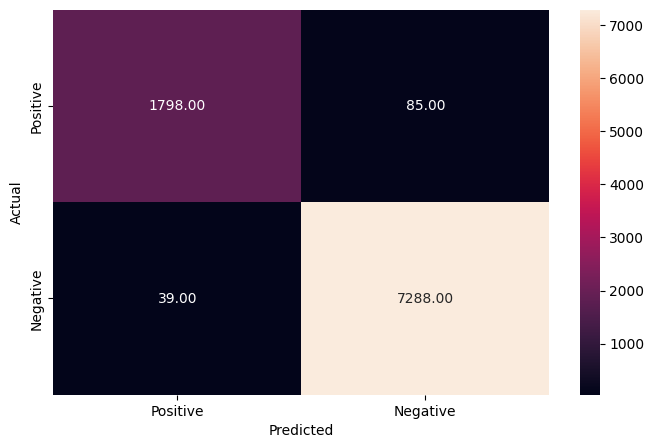

In [131]:
# Rendimiento del modelo en los datos de entrenamiento.
y_pred_train = model.predict(X_train)

metrics_score(y_train, y_pred_train)

**Rendimiento del modelo en los datos test**

              precision    recall  f1-score   support

         0.0       0.72      0.66      0.69       471
         1.0       0.92      0.93      0.92      1832

    accuracy                           0.88      2303
   macro avg       0.82      0.80      0.81      2303
weighted avg       0.88      0.88      0.88      2303



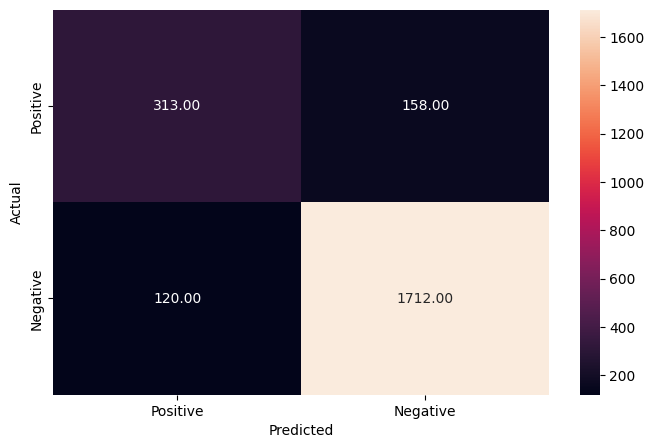

In [132]:
# Realizando predicciones en test set
y_pred = model.predict(X_test)

metrics_score(y_test, y_pred)

* El modelo de Random Forest es capaz de desempeñarse bien para ambas clases presentes en los datos en el conjunto de entrenamiento y prueba a través de los vectores de Bolsa de Palabras.
* Los resultados son consistentes, aunque podemos observar que en datos train el modelo mostró un accuracy general del 99% y el test cayó a 88%, seguramente ajustando los hiperparametros del RF podamos mejorar el accuracy en test.

# **Vectorización TF-IDF**


In [133]:
#Creando el vectirizador tfidf
tfidf = TfidfVectorizer()

# Ajustando y transformar los datos de texto
vectors = tfidf.fit_transform(data['clean_text']).toarray()

# Obtener el tamaño del vocabulario
vocab_size = len(tfidf.vocabulary_)

print("Tamaño del vocabulario: ", vocab_size)
print("Vocabulario: ", tfidf.vocabulary_)

Tamaño del vocabulario:  12026
Vocabulario:  {'virginamerica': 11391, 'dhepburn': 2812, 'said': 9146, 'plus': 8059, 'you': 11966, 'have': 4666, 'added': 131, 'commercial': 2030, 'experience': 3580, 'tacky': 10332, 'did': 2826, 'not': 7281, 'today': 10705, 'must': 6973, 'mean': 6588, 'need': 7061, 'take': 10344, 'another': 497, 'trip': 10877, 'really': 8549, 'aggressive': 219, 'blast': 1134, 'obnoxious': 7383, 'entertainment': 3378, 'guest': 4552, 'face': 3636, 'amp': 426, 'little': 6206, 'recourse': 8611, 'big': 1082, 'bad': 849, 'thing': 10560, 'seriously': 9397, 'would': 11855, 'pay': 7806, 'flight': 3877, 'seat': 9306, 'playing': 8021, 'flying': 3990, 'va': 11292, 'yes': 11949, 'nearly': 7058, 'every': 3482, 'time': 10650, 'fly': 3978, 'vx': 11440, 'ear': 3177, 'worm': 11826, 'will': 11720, 'go': 4383, 'away': 802, 'missed': 6801, 'prime': 8260, 'opportunity': 7526, 'men': 6648, 'without': 11763, 'hat': 4657, 'parody': 7738, 'well': 11602, 'didntbut': 2829, 'amazing': 387, 'arrived'

In [134]:
# Creando el objeto para la clase TfidfVectorizer

vectorizer = TfidfVectorizer(max_features = 200)

In [135]:
# Ajustando y transformando los datos de texto en vectores.
tf_vectors = vectorizer.fit_transform(data['clean_text']).toarray()

In [136]:
# Obteniendo el indexado
print('\nWord indices:')
print(vectorizer.vocabulary_)

# tf-idf values
print('\ntf-idf valores:')
print(tf_vectors)


Word indices:
{'virginamerica': np.int64(181), 'said': np.int64(144), 'you': np.int64(199), 'have': np.int64(78), 'experience': np.int64(53), 'did': np.int64(44), 'not': np.int64(120), 'today': np.int64(168), 'need': np.int64(114), 'take': np.int64(159), 'another': np.int64(11), 'trip': np.int64(174), 'really': np.int64(135), 'amp': np.int64(10), 'bad': np.int64(17), 'thing': np.int64(164), 'would': np.int64(195), 'pay': np.int64(126), 'flight': np.int64(59), 'seat': np.int64(146), 'flying': np.int64(65), 'yes': np.int64(197), 'time': np.int64(167), 'fly': np.int64(64), 'will': np.int64(192), 'go': np.int64(72), 'missed': np.int64(111), 'well': np.int64(190), 'hour': np.int64(84), 'are': np.int64(14), 'good': np.int64(74), 'know': np.int64(93), 'because': np.int64(20), 'much': np.int64(113), 'better': np.int64(22), 'great': np.int64(76), 'already': np.int64(6), 'even': np.int64(51), 'yet': np.int64(198), 'am': np.int64(8), 'travel': np.int64(172), 'thanks': np.int64(162), 'still': np.

In [137]:
print(tf_vectors.shape)

(14604, 200)


In [138]:
tf_vectors[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [139]:
# feature indepediente
X = tf_vectors

# Target feature
y = data["airline_sentiment"].map({'positive':0,'negative':1})

In [140]:
# Dividiendo los datos en conjuntos de entrenamiento y prueba.
# Filtrar los valores NaN de y y el correspondiente X
filtered_indices = ~y.isna()
X_filtered = X[filtered_indices]
y_filtered = y[filtered_indices]

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size = 0.20, random_state = 0, stratify = y_filtered)

In [141]:
print("Shape del Training set : ", X_train.shape)

print("Shape del test set : ", X_test.shape)

print("Porcentaje de clases en training set:")

print(y_train.value_counts(normalize = True))

print("Porcentaje de clases en test set:")

print(y_test.value_counts(normalize = True))

Shape del Training set :  (9210, 200)
Shape del test set :  (2303, 200)
Porcentaje de clases en training set:
airline_sentiment
1.0    0.795548
0.0    0.204452
Name: proportion, dtype: float64
Porcentaje de clases en test set:
airline_sentiment
1.0    0.795484
0.0    0.204516
Name: proportion, dtype: float64


In [142]:
# Iniciando el modelo de Random Forest.
model = RandomForestClassifier(random_state = 1)

# Ajustando el modelo en el conjunto de entrenamiento.
model.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

**Model performance on the training data**

              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97      1883
         1.0       0.99      0.99      0.99      7327

    accuracy                           0.99      9210
   macro avg       0.98      0.98      0.98      9210
weighted avg       0.99      0.99      0.99      9210



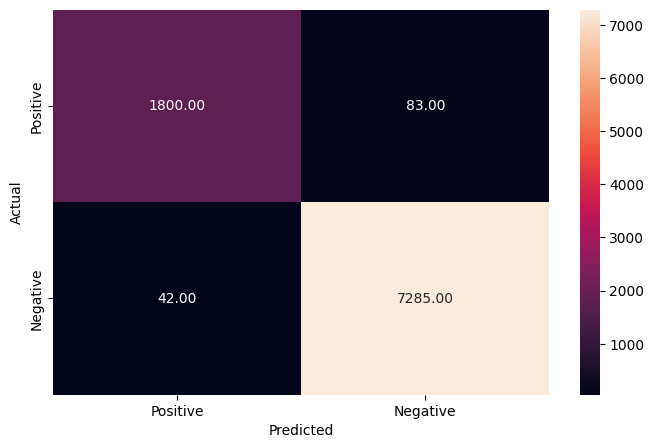

In [143]:
# Realizando predicciones en el conjunto de pruebas.
y_pred_train = model.predict(X_train)

metrics_score(y_train, y_pred_train)

La precisión del modelo en los datos de entrenamiento fue del 99%.
Echemos un vistazo a la puntuación en los datos de prueba para verificar si el modelo está funcionando bien o si ha sobreajustado los datos.

**Model performance on the testing data**

              precision    recall  f1-score   support

         0.0       0.74      0.60      0.67       471
         1.0       0.90      0.95      0.92      1832

    accuracy                           0.88      2303
   macro avg       0.82      0.77      0.79      2303
weighted avg       0.87      0.88      0.87      2303



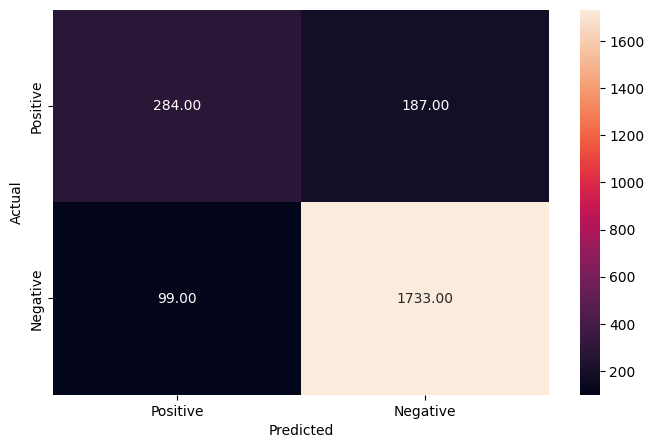

In [144]:
# Rendimiento del modelo en test set
y_pred = model.predict(X_test)

metrics_score(y_test, y_pred)

* Para este caso podemos observar que el rendimieto del modelo de clasificacion utilizazndo Bag of Word y Vectorizador Tf-IDF es bastante similar sin aplicar un fine tunnig.
* En general podemos ver que el modelo es muy preciso para clasificar los comentarios negativos con un 90% de certeza, pero no tanto cuando se trata de comentarios positivos 74%. Lo cual lo podemos confirmar al ver el Recall.



# **Conclusión del caso de negocio**



1. Hallazgos Principales Correlación de Servicio: Se identificó que las aerolíneas con mejores reseñas mantienen un servicio al cliente sólido y consistente.La mayoría de las quejas de los viajeros se concentran en:Vuelos cancelados o retrasados.Problemas con los horarios y el proceso de reserva.Deficiencias en el servicio al cliente (que también es el principal detonante de comentarios negativos).


2. La recomendación Estratégica fue realizar un benchmark profundo con Virgin America. El objetivo es identificar las mejores prácticas que las distinguen y que generan una alta aceptación entre los usuarios, para así replicar ese éxito en la nueva aerolínea.

3. Para garantizar la calidad del modelo de clasificación, definimos que no basta con medir la exactitud. Es fundamental monitorear la precisión, la sensibilidad y, especialmente, el F1-Score, debido al probable desbalance de datos (más quejas que elogios) en redes sociales.

**Conclusión del proyecto**

1. Preprocesamiento: La limpieza de datos (normalización, eliminación de ruido y lematización) fue fundamental para reducir la dimensionalidad del lenguaje. El uso de TF-IDF y Bag of Words mostró resultados equiparables, validando la robustez de los vectores generados para la clasificación.

2. Análisis de comentarios: Los datos confirman un fuerte sesgo hacia el sentimiento negativo (62% del dataset), reflejando la naturaleza de Twitter como canal de quejas. Este desbalanceo de clases resultó en un modelo con una sensibilidad superior para identificar detractores, logrando un 90% de precisión en la clase negativa.

3. Evaluación del Modelo: El algoritmo Random Forest demostró una alta capacidad de aprendizaje (99% en entrenamiento), aunque se identificó un ligero sobreajuste (overfitting) al estabilizarse en un 88% de precisión en el set de prueba. Esto indica que el modelo es altamente confiable para la categorización automatizada de menciones en tiempo real.

4. Valor de Negocio: La investigación concluye que el servicio al cliente es el atributo más valorado por el viajero. Por tanto, cualquier estrategia de posicionamiento para la nueva aerolínea debe priorizar la eficiencia operativa en reservas y el cumplimiento de horarios como pilares de comunicación.



**FIN DEL NOTEBOOK**